### **Analyzing the Adoption of Electric Vehicles in the Indian Market**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA

#survey reponses
survey = pd.read_excel("EV Adoption Survey (Responses).xlsx")

#Indian public/state/infra datasets
ev_dataset = pd.read_csv("EV_Dataset.csv")
ev_sales = pd.read_excel("Ev Sales.xlsx")
infra = pd.read_csv("OperationalPC.csv")
final_state = pd.read_csv("final_dataset.csv")
ev_cat = pd.read_csv("ev_cat_01-24.csv")
ev_sales_brand = pd.read_csv("ev_sales_by_makers_and_cat_15-24.csv")
vehicle_class = pd.read_csv("Vehicle Class - All.csv")
rs_state = pd.read_csv("RS_Session_259_AU_3475_1.csv")
rs_year = pd.read_csv("RS_Session_265_AU_1355_A_and_B.csv")

#global benchmark data
iea_global = pd.read_csv("IEA Global EV Data 2024.csv")


In [ ]:
dfs = {
    'survey': survey,
    'ev_dataset': ev_dataset,
    'ev_sales': ev_sales,
    'infra': infra,
    'final_state': final_state,
    'ev_cat': ev_cat,
    'ev_sales_brand': ev_sales_brand,
    'vehicle_class': vehicle_class,
    'rs_state': rs_state,
    'rs_year': rs_year,
    'iea_global': iea_global
}

for name, df in dfs.items():
    print(f"\n{name.upper()} shape: {df.shape}")
    print(f"{name.upper()} columns: {list(df.columns)}")
    print(df.head(2))



SURVEY shape: (205, 28)
SURVEY columns: ['Timestamp', 'What is your age group?', 'What is your gender?  ', '  What is your nationality?  ', 'What is your residential status?( for Indian nationals)', '  Where do you currently reside?  ', '  What type of area do you live in?  ', ' What is your highest level of education?  ', '  What is your current employment status?  ', 'What is your average monthly personal income (in INR)?  ', 'How would you describe your financial situation?  ', 'Do you currently own any personal vehicle(s)?', 'What type of vehicle(s) do you own? (Select all that apply)', 'How old is your primary vehicle?', 'What is your average monthy travel distance with your personal vehicle?', 'How familiar are you with electric vehicle ( EVs)', 'What is your overall opinion of EVs?', 'Where did you first hear about EVs? (Select all that apply)', 'What benefits do you associate with EVs? ( Select all that apply)', 'What concerns or drawbacks do you associate with EVs? ( Select a

In [ ]:
# Remove leading and trailing spaces from all column names
survey.columns = survey.columns.str.strip().str.replace('\n', '').str.replace('  ', ' ').str.replace('?', '').str.replace('(', '').str.replace(')', '').str.replace('  ', ' ')

# Print new column names
print(list(survey.columns))


['Timestamp', 'What is your age group', 'What is your gender', 'What is your nationality', 'What is your residential status for Indian nationals', 'Where do you currently reside', 'What type of area do you live in', 'What is your highest level of education', 'What is your current employment status', 'What is your average monthly personal income in INR', 'How would you describe your financial situation', 'Do you currently own any personal vehicles', 'What type of vehicles do you own Select all that apply', 'How old is your primary vehicle', 'What is your average monthy travel distance with your personal vehicle', 'How familiar are you with electric vehicle EVs', 'What is your overall opinion of EVs', 'Where did you first hear about EVs Select all that apply', 'What benefits do you associate with EVs Select all that apply', 'What concerns or drawbacks do you associate with EVs Select all that apply', 'Do you feel EVs are suitable for your area', 'Are you aware of any government policies 

In [ ]:
# Standardize column names: replace multiple spaces with one
survey.columns = survey.columns.str.replace('\s+', ' ', regex=True).str.strip()
print(list(survey.columns))


['Timestamp', 'What is your age group', 'What is your gender', 'What is your nationality', 'What is your residential status for Indian nationals', 'Where do you currently reside', 'What type of area do you live in', 'What is your highest level of education', 'What is your current employment status', 'What is your average monthly personal income in INR', 'How would you describe your financial situation', 'Do you currently own any personal vehicles', 'What type of vehicles do you own Select all that apply', 'How old is your primary vehicle', 'What is your average monthy travel distance with your personal vehicle', 'How familiar are you with electric vehicle EVs', 'What is your overall opinion of EVs', 'Where did you first hear about EVs Select all that apply', 'What benefits do you associate with EVs Select all that apply', 'What concerns or drawbacks do you associate with EVs Select all that apply', 'Do you feel EVs are suitable for your area', 'Are you aware of any government policies 

In [ ]:
# Get data types and missing value counts for each column
print(survey.info())
print(survey.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 28 columns):
 #   Column                                                                                  Non-Null Count  Dtype         
---  ------                                                                                  --------------  -----         
 0   Timestamp                                                                               205 non-null    datetime64[ns]
 1   What is your age group                                                                  205 non-null    object        
 2   What is your gender                                                                     205 non-null    object        
 3   What is your nationality                                                                205 non-null    object        
 4   What is your residential status for Indian nationals                                    205 non-null    object        
 5   Where do you currently

In [ ]:
# first 3 rows
print(survey.head(3))


                Timestamp What is your age group What is your gender  \
0 2025-06-06 11:25:26.812                  45–54              Female   
1 2025-06-06 11:35:53.705                  55–64              Female   
2 2025-06-06 11:36:15.351                  45–54              Female   

  What is your nationality  \
0                   Indian   
1                   Indian   
2                   Indian   

  What is your residential status for Indian nationals  \
0                       Non - Resident Indian ( NRI)     
1                                    Indian Resident     
2                       Non - Resident Indian ( NRI)     

  Where do you currently reside What type of area do you live in  \
0                        Qatar                        Metro city   
1                         Qatar                       Metro city   
2                        Qatar                        Metro city   

  What is your highest level of education  \
0                     Postgraduate degr

## **SURVEY DATA EDA**

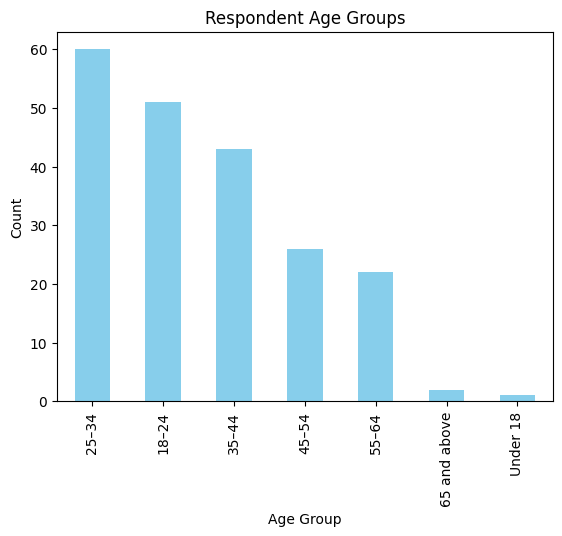

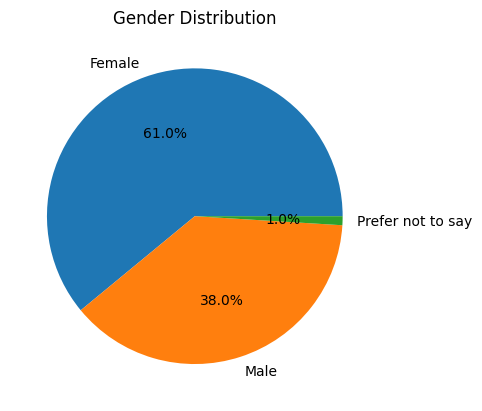

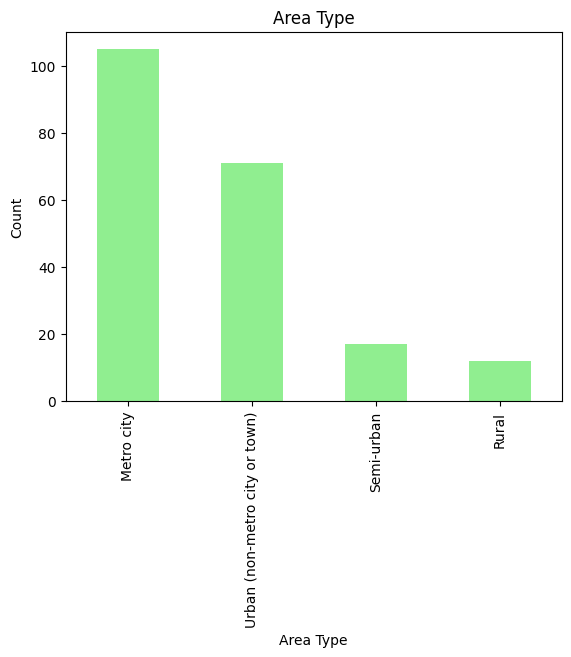

In [ ]:
#Demographics

# Age group distribution
survey['What is your age group'].value_counts().plot(kind='bar', color='skyblue', title='Respondent Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

# Gender distribution
survey['What is your gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Gender Distribution')
plt.ylabel('')
plt.show()

# Area type
survey['What type of area do you live in'].value_counts().plot(kind='bar', color='lightgreen', title='Area Type')
plt.xlabel('Area Type')
plt.ylabel('Count')
plt.show()


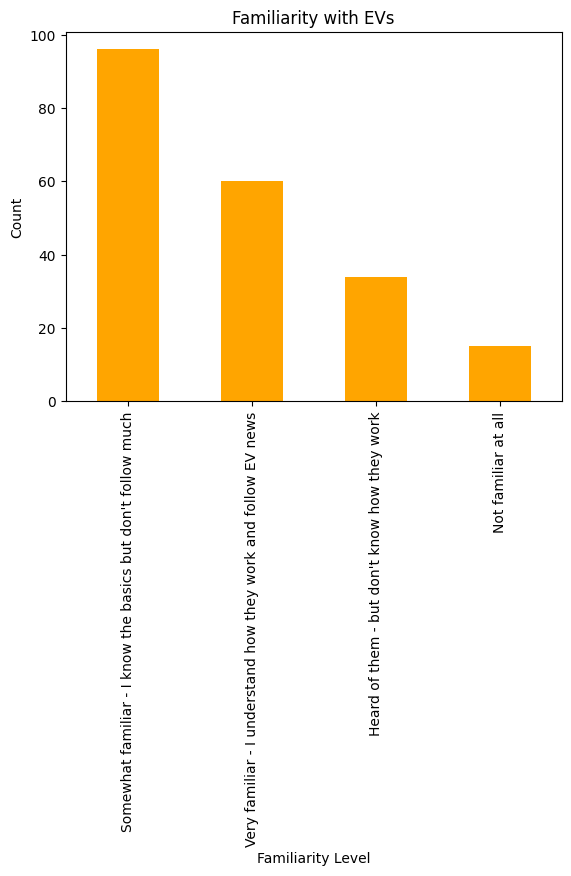

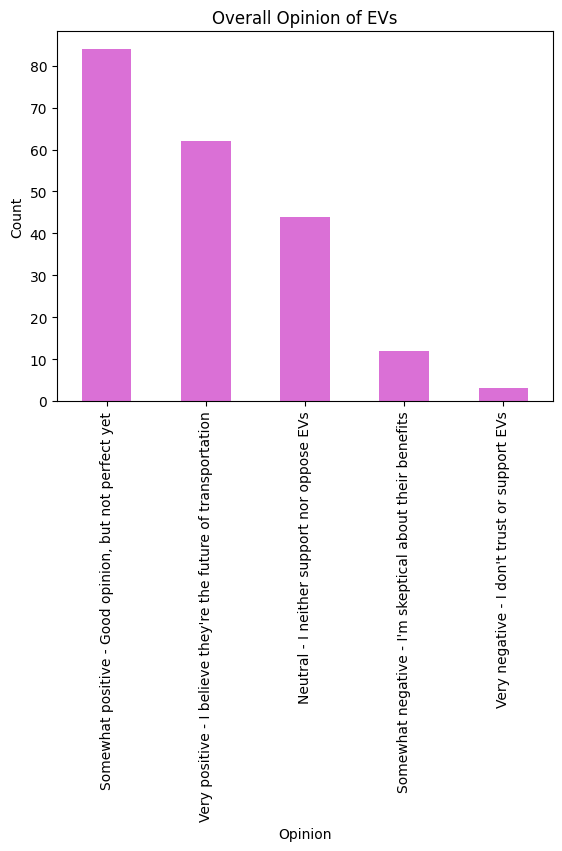

In [ ]:
#EV Awareness and Perception

# Familiarity with EVs
survey['How familiar are you with electric vehicle EVs'].value_counts().plot(kind='bar', color='orange', title='Familiarity with EVs')
plt.xlabel('Familiarity Level')
plt.ylabel('Count')
plt.show()

# Overall opinion of EVs
survey['What is your overall opinion of EVs'].value_counts().plot(kind='bar', color='orchid', title='Overall Opinion of EVs')
plt.xlabel('Opinion')
plt.ylabel('Count')
plt.show()


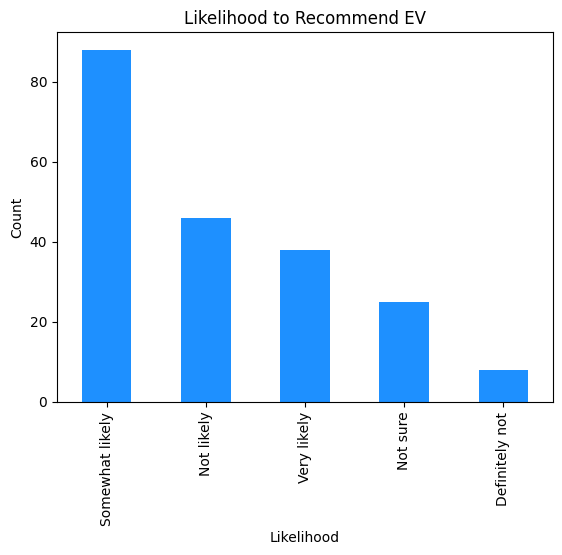

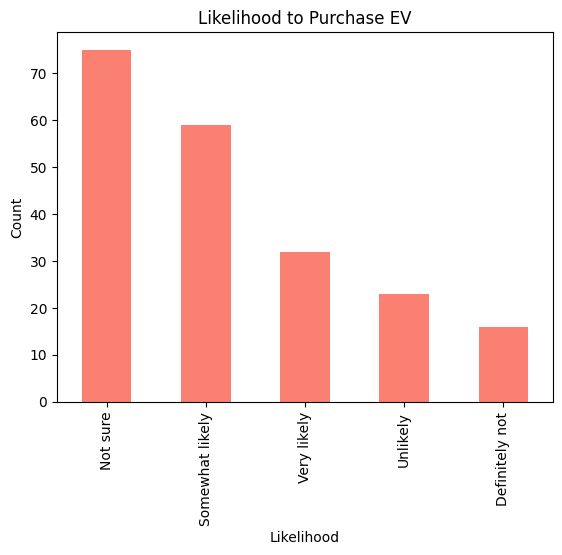

In [ ]:
#Intent to Adopt/Recommend EVs

# Likelihood to recommend
survey['How likely are you to recommend an EV to someone else'].value_counts().plot(kind='bar', color='dodgerblue', title='Likelihood to Recommend EV')
plt.xlabel('Likelihood')
plt.ylabel('Count')
plt.show()

# Likelihood to purchase as next vehicle
survey['How likely are you to purchase an electric vehicle as your next vehicle'].value_counts().plot(kind='bar', color='salmon', title='Likelihood to Purchase EV')
plt.xlabel('Likelihood')
plt.ylabel('Count')
plt.show()


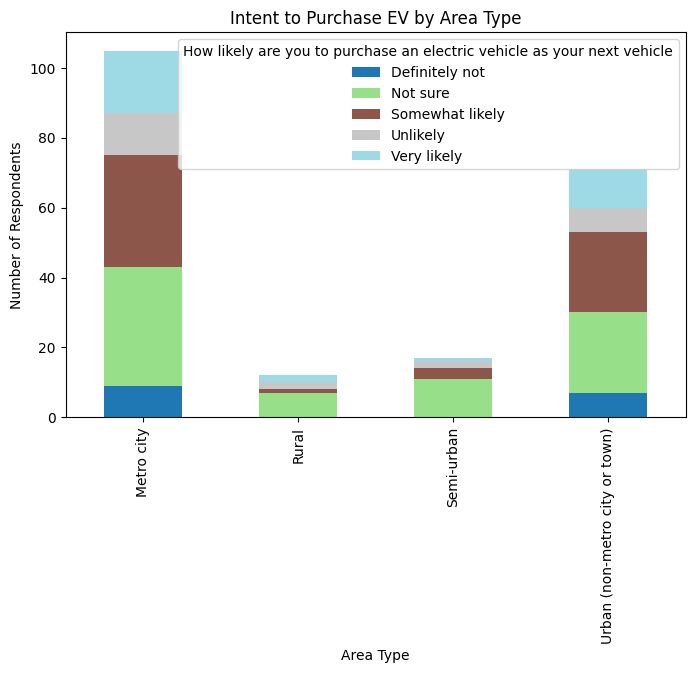

In [ ]:
#area type

pd.crosstab(
    survey['What type of area do you live in'],
    survey['How likely are you to purchase an electric vehicle as your next vehicle']
).plot(kind='bar', stacked=True, figsize=(8,5), colormap='tab20')
plt.title('Intent to Purchase EV by Area Type')
plt.xlabel('Area Type')
plt.ylabel('Number of Respondents')
plt.show()


In [ ]:
#Key Multi-Select & Target Variables

from collections import Counter

def multi_select_counts(column):
    # Split responses, flatten, and count frequencies
    all_answers = survey[column].dropna().str.split(',').explode().str.strip()
    return Counter(all_answers)

# Benefits people associate with EVs
benefits_counts = multi_select_counts('What benefits do you associate with EVs Select all that apply')
print("Top EV benefits:", benefits_counts.most_common(8))

# Drawbacks/concerns
concerns_counts = multi_select_counts('What concerns or drawbacks do you associate with EVs Select all that apply')
print("Top EV concerns:", concerns_counts.most_common(8))

# Motivators
motivators_counts = multi_select_counts('What would motivate you to consider switching to an EV Select all that apply')
print("Top motivators:", motivators_counts.most_common(8))


Top EV benefits: [('Lower fuel / energy cost', 146), ('Reduced environmental pollution', 142), ('Silent / smooth driving experience', 87), ('Government subsidies and tax benefits', 49), ('Lower maintenance', 42), ('Trendy / modern image', 36), ('None/ not sure', 14), ('feel very less power', 1)]
Top EV concerns: [('Lack of charging infrastructure', 119), ('High initial cost', 109), ('Battery replacement cost', 100), ('Limited driving range', 93), ('Long charging time', 93), ('Unsure about resale value', 68), ('Safety doubts', 58), ('Performance concerns', 45)]
Top motivators: [('Better charging infrastructure', 95), ('Environmental impact', 89), ('Lower purchase cost', 81), ('Faster charging times', 79), ('Higher fuel prices for traditional vehicles', 63), ('More government incentives', 46), ('Peer influence / social trend', 14), ('Performance and features', 1)]


In [ ]:
#Prepare Target Variable for Modeling

# Combine 'Very likely' and 'Somewhat likely' as positive (1), others as negative (0)
survey['Likely_to_Adopt_EV'] = survey['How likely are you to purchase an electric vehicle as your next vehicle'].map(
    lambda x: 1 if 'very likely' in x.lower() or 'somewhat likely' in x.lower() else 0
)

print(survey['Likely_to_Adopt_EV'].value_counts())


Likely_to_Adopt_EV
0    114
1     91
Name: count, dtype: int64


In [ ]:
#Gender vs. Likelihood to Adopt

pd.crosstab(survey['What is your gender'], survey['How likely are you to purchase an electric vehicle as your next vehicle'])


How likely are you to purchase an electric vehicle as your next vehicle,Definitely not,Not sure,Somewhat likely,Unlikely,Very likely
What is your gender,,,,,
Female,11,58,29,10,17
Male,5,16,30,12,15
Prefer not to say,0,1,0,1,0


In [ ]:
#Survey Data Modeling

# Select columns for features
features = [
    'What is your age group',
    'What is your gender',
    'What type of area do you live in',
    'What is your highest level of education',
    'What is your current employment status',
    'What is your average monthly personal income in INR',
    'How would you describe your financial situation',
    'How familiar are you with electric vehicle EVs',
    'What is your overall opinion of EVs',
    'Do you currently own any personal vehicles',
    'How old is your primary vehicle',
    'What is your average monthy travel distance with your personal vehicle',
]

# One-hot encode categorical features
X = pd.get_dummies(survey[features], drop_first=True)
y = survey['Likely_to_Adopt_EV']


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Accuracy
print("Model accuracy:", model.score(X_test, y_test))


Model accuracy: 0.7560975609756098


In [ ]:
# Show feature importances
importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print(importance.head(10))
print(importance.tail(10))


What is your overall opinion of EVs_Very positive - I believe they're the future of transportation    2.791150
What is your overall opinion of EVs_Somewhat positive - Good opinion, but not perfect yet             1.349864
What is your average monthly personal income in INR_₹1,00,001 – ₹2,00,000 (≈ $1,200–$2,400)           0.831655
What is your gender_Male                                                                              0.822827
What is your average monthy travel distance with your personal vehicle_not applicable                 0.792704
What is your age group_35–44                                                                          0.655383
What is your current employment status_Employed – Private sector                                      0.653846
What is your current employment status_Retired – Without pension                                      0.649246
What is your highest level of education_Graduate                                                      0.646211
W

## **PUBLIC DATA ANALYSIS**

In [ ]:
#  EV_Dataset.csv (Statewise & Category Trends)

# Quick structure and sample
print(ev_dataset.info())
print(ev_dataset.head(3))

# Check time range and states
print("Years:", ev_dataset['Year'].unique())
print("States:", ev_dataset['State'].unique()[:10])
print("Vehicle Classes:", ev_dataset['Vehicle_Class'].unique())
print("Vehicle Categories:", ev_dataset['Vehicle_Category'].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB
None
     Year Month_Name      Date           State         Vehicle_Class  \
0  2014.0        jan  1/1/2014  Andhra Pradesh       ADAPTED VEHICLE   
1  2014.0        jan  1/1/2014  Andhra Pradesh  AGRICULTURAL TRACTOR   
2  2014.0        jan  1/1/2014  Andhra Pradesh             AMBULANCE   

  Vehicle_Category Vehicle_Type  EV_Sales_Quantity  
0           O

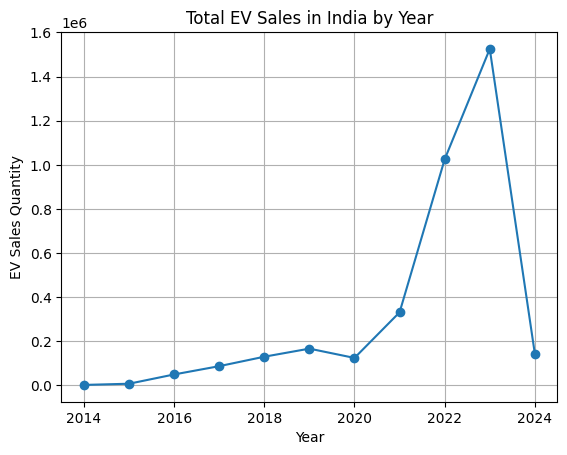

In [ ]:
#Total EV Sales Trend (All India)

# Remove missing years
ev_dataset = ev_dataset.dropna(subset=['Year'])

# All-India yearly EV sales
yearly_sales = ev_dataset.groupby('Year')['EV_Sales_Quantity'].sum()
yearly_sales.plot(kind='line', marker='o', title='Total EV Sales in India by Year')
plt.xlabel('Year')
plt.ylabel('EV Sales Quantity')
plt.grid(True)
plt.show()


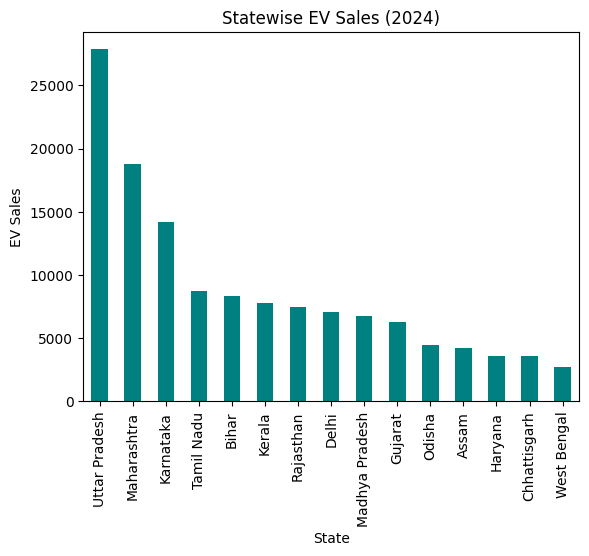

In [ ]:
#Statewise EV Adoption (Latest Year)

# Find latest year in dataset
latest_year = ev_dataset['Year'].max()
state_latest = ev_dataset[ev_dataset['Year'] == latest_year]
state_sales = state_latest.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False)

state_sales.head(15).plot(kind='bar', color='teal', title=f'Statewise EV Sales ({int(latest_year)})')
plt.xlabel('State')
plt.ylabel('EV Sales')
plt.show()


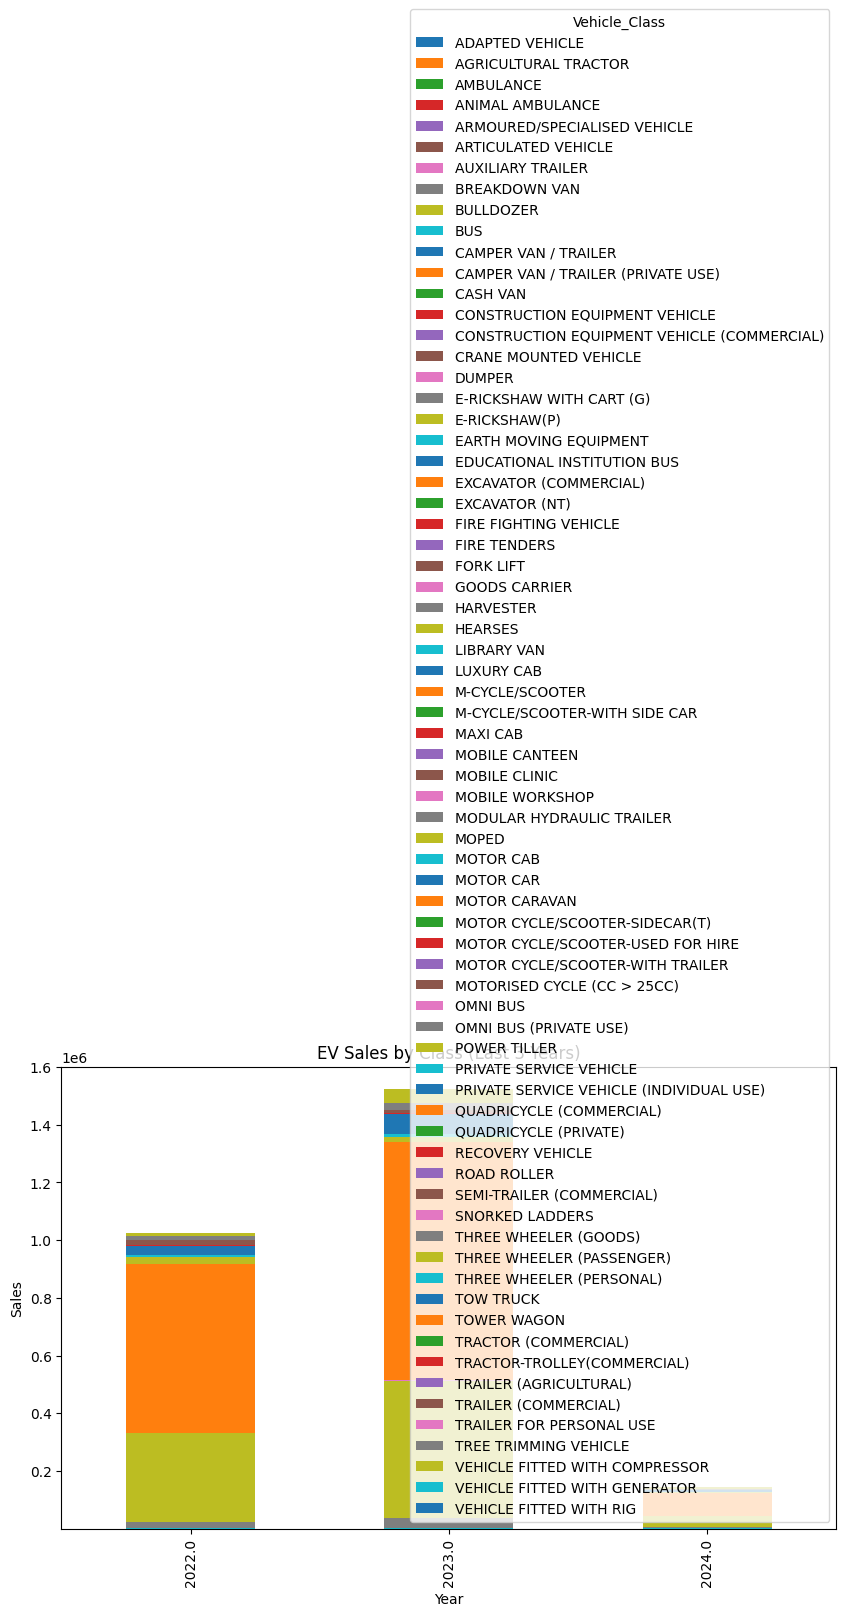

In [ ]:
#Vehicle Class Trend (All India, Last 3 Years)

# Select last 3 years
recent_years = sorted(ev_dataset['Year'].dropna().unique())[-3:]
class_trends = ev_dataset[ev_dataset['Year'].isin(recent_years)].groupby(['Year', 'Vehicle_Class'])['EV_Sales_Quantity'].sum().unstack()

class_trends.plot(kind='bar', stacked=True, figsize=(10,6), title='EV Sales by Class (Last 3 Years)')
plt.ylabel('Sales')
plt.show()


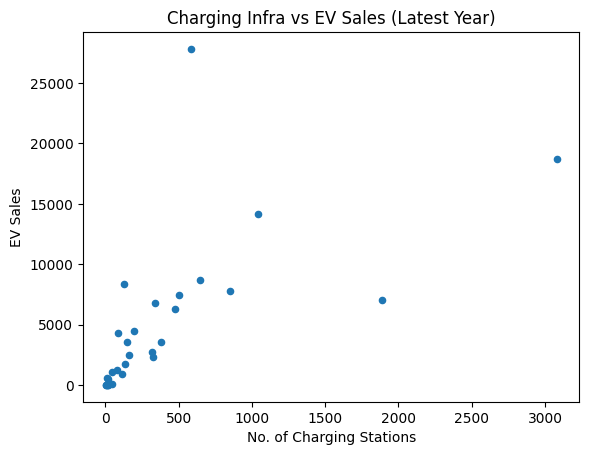

In [ ]:
#Charging Infrastructure vs. Adoption

# Merge state sales with infra data for latest year
infra_merged = state_sales.reset_index().merge(infra, left_on='State', right_on='State', how='left')
infra_merged.plot.scatter(x='No. of Operational PCS', y='EV_Sales_Quantity', title='Charging Infra vs EV Sales (Latest Year)')
plt.xlabel('No. of Charging Stations')
plt.ylabel('EV Sales')
plt.show()


        YEAR  2 W   3 W  4 W  BUS  TOTAL
0 2017-04-01   96  4748  198    0   5042
1 2017-05-01   91  6720  215    2   7028
2 2017-06-01  137  7178  149    1   7465
3 2017-07-01  116  8775  120    0   9011
4 2017-08-01   99  8905  137    0   9141


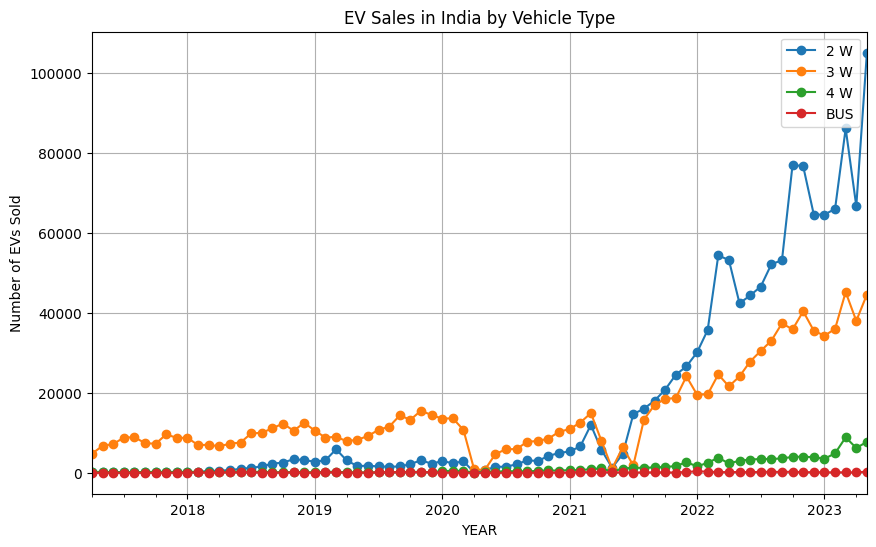

In [ ]:
# National Trends by Vehicle Type

#Ev Sales.xlsx
print(ev_sales.head())

# Cleaning
ev_sales.columns = [col.strip() for col in ev_sales.columns]

# Set YEAR as datetime
ev_sales['YEAR'] = pd.to_datetime(ev_sales['YEAR'], errors='coerce')

# Plot total EV sales by type over time
ev_sales.set_index('YEAR')[['2 W', '3 W', '4 W', 'BUS']].plot(
    figsize=(10,6), marker='o', title='EV Sales in India by Vehicle Type'
)
plt.ylabel('Number of EVs Sold')
plt.grid(True)
plt.show()


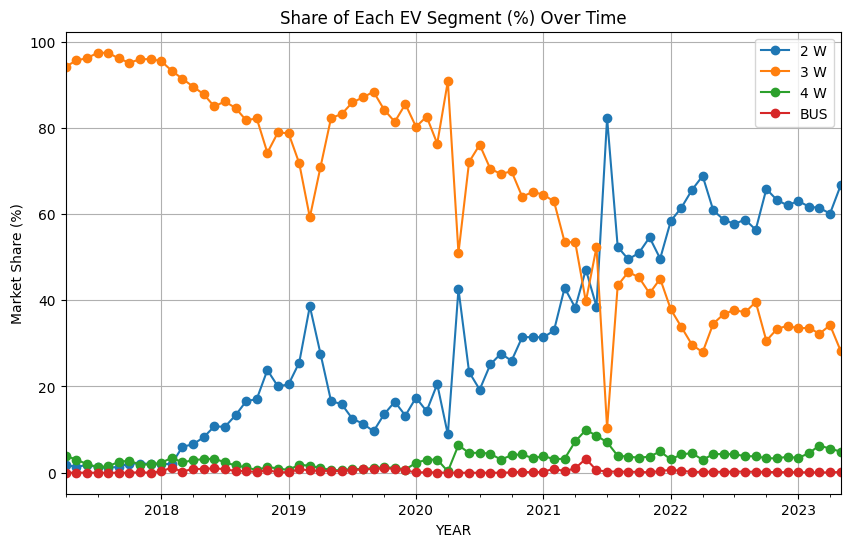

In [ ]:
#Calculate % Share by Segment

segment_share = ev_sales[['2 W', '3 W', '4 W', 'BUS']].div(ev_sales['TOTAL'], axis=0) * 100
segment_share['YEAR'] = ev_sales['YEAR']
segment_share.set_index('YEAR').plot(
    figsize=(10,6), marker='o', title='Share of Each EV Segment (%) Over Time'
)
plt.ylabel('Market Share (%)')
plt.grid(True)
plt.show()


In [ ]:
#Brand & State Segmentation

print(ev_sales_brand.head())
ev_sales_brand.columns = [col.strip() for col in ev_sales_brand.columns]


  Cat                          Maker  2015  2016  2017  2018  2019  2020  \
0  3W    "VOLVO GROUP INDIA PVT LTD"     0     0    31    12     0     0   
1  3W         3EV INDUSTRIES PVT LTD     0     0     0     0     0     0   
2  2W         3GB TECHNOLOGY PVT LTD     0     0     0     1     0     0   
3  3W         3GB TECHNOLOGY PVT LTD     0     1     1     0     0     0   
4  3W  3S INDUSTRIES PRIVATE LIMITED     0     0     0     0    48    66   

   2021  2022  2023  2024  
0     0     0     0     0  
1   112   390   545    51  
2     0     0     0     0  
3     0     0     0     0  
4    43    68   266   578  


In [ ]:
#Top Brands by Category (2W, 3W, 4W) for 2023

# Convert columns to numeric for years
for year in ['2022', '2023', '2024']:
    ev_sales_brand[year] = pd.to_numeric(ev_sales_brand[year], errors='coerce')

# top brands for each vehicle category in 2023
for category in ['2W', '3W', '4W']:
    print(f"\nTop 10 {category} brands in 2023:")
    top = ev_sales_brand[ev_sales_brand['Cat']==category].sort_values('2023', ascending=False).head(10)
    print(top[['Maker', '2023']])



Top 10 2W brands in 2023:
                                  Maker    2023
867   OLA ELECTRIC TECHNOLOGIES PVT LTD  267355
1230              TVS MOTOR COMPANY LTD  166580
118                ATHER ENERGY PVT LTD  104735
148                      BAJAJ AUTO LTD   71940
76      AMPERE VEHICLES PRIVATE LIMITED   42903
864            OKINAWA AUTOTECH PVT LTD   31616
472     HERO ELECTRIC VEHICLES PVT. LTD   29964
424   GREAVES ELECTRIC MOBILITY PVT LTD   24045
863                    OKAYA EV PVT LTD   15816
171         BGAUSS AUTO PRIVATE LIMITED   11454

Top 10 3W brands in 2023:
                                Maker   2023
1357              YC ELECTRIC VEHICLE  40794
749       MAHINDRA & MAHINDRA LIMITED  37942
1020      SAERA ELECTRIC AUTO PVT LTD  29321
264       DILLI ELECTRIC AUTO PVT LTD  25071
909          PIAGGIO VEHICLES PVT LTD  21079
794               MINI METRO EV L.L.P  15962
204               CHAMPION POLY PLAST  14877
1248             UNIQUE INTERNATIONAL  13572
502          

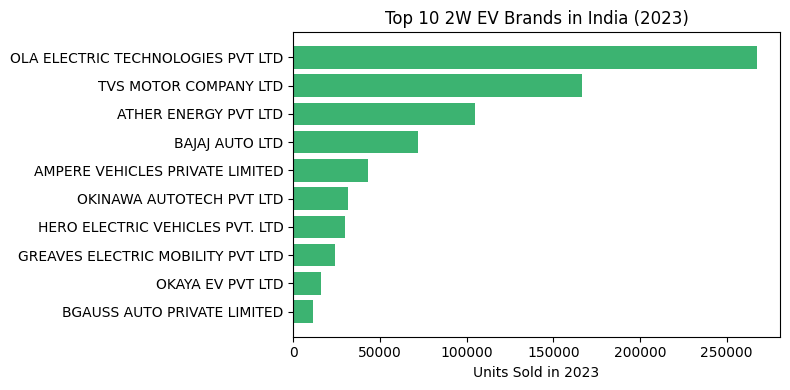

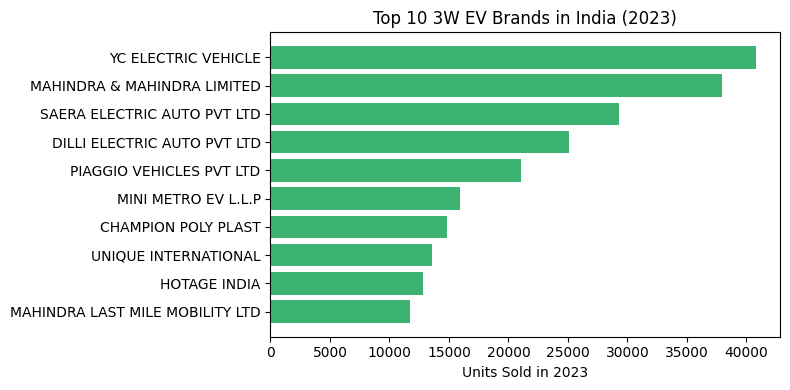

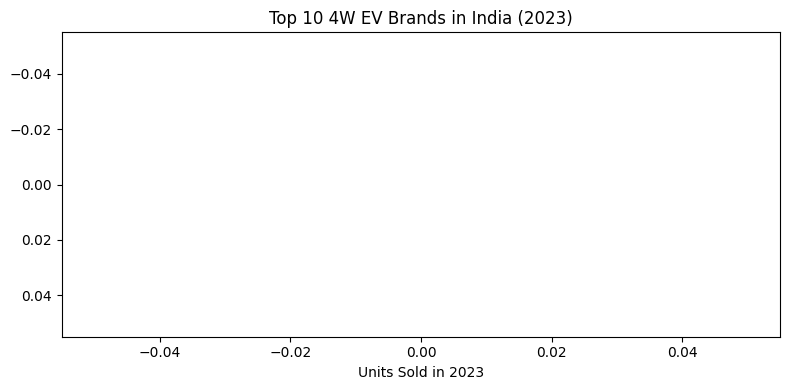

In [ ]:
#Plot Top Brands for Each Category

for category in ['2W', '3W', '4W']:
    top = ev_sales_brand[ev_sales_brand['Cat']==category].sort_values('2023', ascending=False).head(10)
    plt.figure(figsize=(8,4))
    plt.barh(top['Maker'], top['2023'], color='mediumseagreen')
    plt.xlabel('Units Sold in 2023')
    plt.title(f'Top 10 {category} EV Brands in India (2023)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


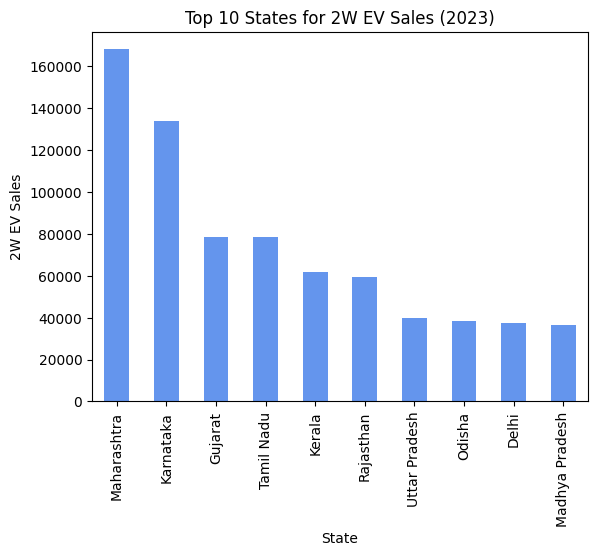

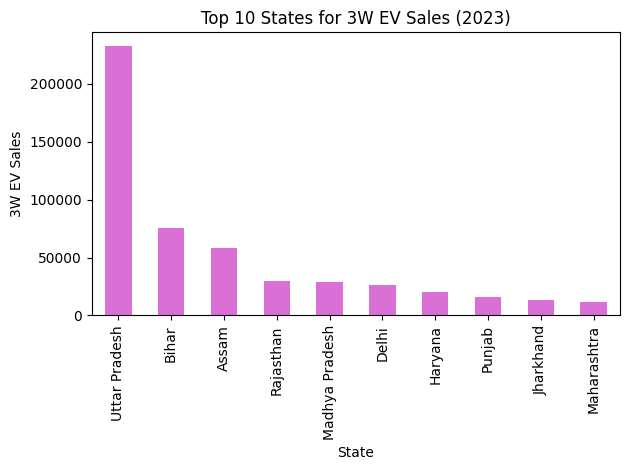

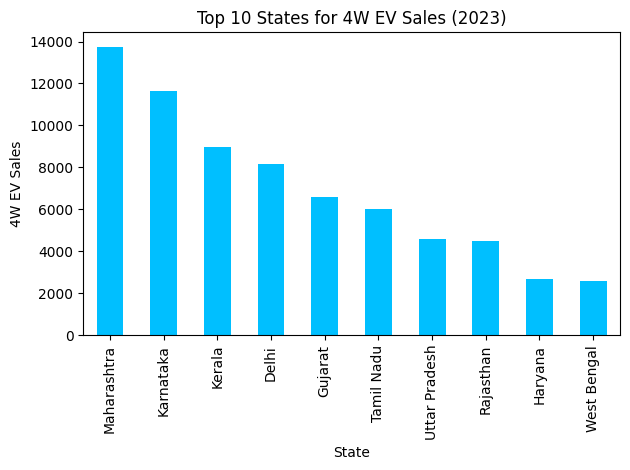

In [ ]:
# Top states for 2W sales in 2023
top_states_2w = ev_dataset[
    (ev_dataset['Year'] == 2023) &
    (ev_dataset['Vehicle_Category'].str.contains('2-Wheelers'))
].groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

top_states_2w.plot(kind='bar', color='cornflowerblue', title='Top 10 States for 2W EV Sales (2023)')
plt.ylabel('2W EV Sales')
plt.xlabel('State')
plt.show()

# Top states for 3W sales in 2023
top_states_3w = ev_dataset[
    (ev_dataset['Year'] == 2023) &
    (ev_dataset['Vehicle_Category'].str.contains('3-Wheelers'))
].groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

top_states_3w.plot(kind='bar', color='orchid', title='Top 10 States for 3W EV Sales (2023)')
plt.ylabel('3W EV Sales')
plt.xlabel('State')
plt.tight_layout()
plt.show()


# Top states for 4W sales in 2023
top_states_4w = ev_dataset[
    (ev_dataset['Year'] == 2023) &
    (ev_dataset['Vehicle_Category'].str.contains('4-Wheelers'))
].groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False).head(10)

top_states_4w.plot(kind='bar', color='deepskyblue', title='Top 10 States for 4W EV Sales (2023)')
plt.ylabel('4W EV Sales')
plt.xlabel('State')
plt.tight_layout()
plt.show()



                State  Sales_2019  Sales_2023      CAGR
17             Ladakh         0.0        28.0       inf
9                 Goa        41.0      9440.0  2.895355
22            Mizoram         1.0       166.0  2.589443
16             Kerala       471.0     74714.0  2.548912
13  Jammu and Kashmir        76.0      9720.0  2.362894
10            Gujarat       945.0     88617.0  2.111869
24             Odisha      1159.0     44552.0  1.489980
25         Puducherry        80.0      2637.0  1.396101
26             Punjab       961.0     25741.0  1.274969
19        Maharashtra      7319.0    193935.0  1.268826


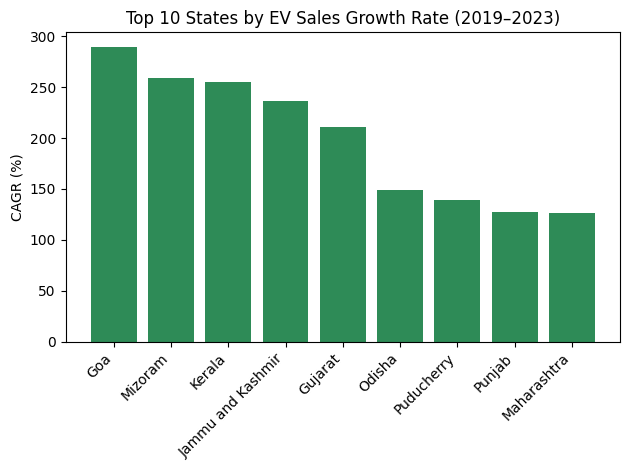

In [ ]:
#Calculate CAGR for Top States (2019 to 2023)

# Get sales in 2019 and 2023
sales_2019 = ev_dataset[ev_dataset['Year'] == 2019].groupby('State')['EV_Sales_Quantity'].sum().reset_index().rename(columns={'EV_Sales_Quantity': 'Sales_2019'})
sales_2023 = ev_dataset[ev_dataset['Year'] == 2023].groupby('State')['EV_Sales_Quantity'].sum().reset_index().rename(columns={'EV_Sales_Quantity': 'Sales_2023'})

# Merge on State
sales_growth = sales_2019.merge(sales_2023, on='State', how='inner')

# CAGR formula: ((Ending/Beginning)^(1/Years))-1
years = 2023 - 2019
sales_growth['CAGR'] = ((sales_growth['Sales_2023'] / sales_growth['Sales_2019']) ** (1/years)) - 1

# Sort and show top states by growth rate
sales_growth = sales_growth.sort_values('CAGR', ascending=False)
print(sales_growth[['State', 'Sales_2019', 'Sales_2023', 'CAGR']].head(10))


top_growth = sales_growth.head(10)
plt.bar(top_growth['State'], top_growth['CAGR']*100, color='seagreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel('CAGR (%)')
plt.title('Top 10 States by EV Sales Growth Rate (2019–2023)')
plt.tight_layout()
plt.show()



## **INTERNATIONAL BENCHMARKING (IEA DATA)**

In [ ]:
#Dataset preview
print(iea_global.head())
print(iea_global['region'].unique())


      region    category       parameter  mode powertrain  year      unit  \
0  Australia  Historical  EV stock share  Cars         EV  2011   percent   
1  Australia  Historical  EV sales share  Cars         EV  2011   percent   
2  Australia  Historical        EV sales  Cars        BEV  2011  Vehicles   
3  Australia  Historical        EV stock  Cars        BEV  2011  Vehicles   
4  Australia  Historical        EV stock  Cars        BEV  2012  Vehicles   

       value  
0    0.00039  
1    0.00650  
2   49.00000  
3   49.00000  
4  220.00000  
['Australia' 'Austria' 'Belgium' 'Brazil' 'Bulgaria' 'Canada' 'Chile'
 'China' 'Colombia' 'Costa Rica' 'Croatia' 'Cyprus' 'Czech Republic'
 'Denmark' 'Estonia' 'EU27' 'Europe' 'Finland' 'France' 'Germany' 'Greece'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Ireland' 'Israel' 'Italy'
 'Japan' 'Korea' 'Latvia' 'Lithuania' 'Luxembourg' 'Mexico' 'Netherlands'
 'New Zealand' 'Norway' 'Poland' 'Portugal' 'Rest of the world' 'Romania'
 'Seychelles' 'Sl

In [ ]:
#check region names
for r in ['India', 'China', 'USA', 'World']:
    print(r, ":", any(iea_global['region'].str.lower().str.contains(r.lower())))


print([region for region in iea_global['region'].unique() if 'eu' in region.lower() or 'europe' in region.lower()])


India : True
China : True
USA : True
World : True
['EU27', 'Europe']


In [ ]:
regions = ['India', 'China', 'EU27', 'USA', 'World']


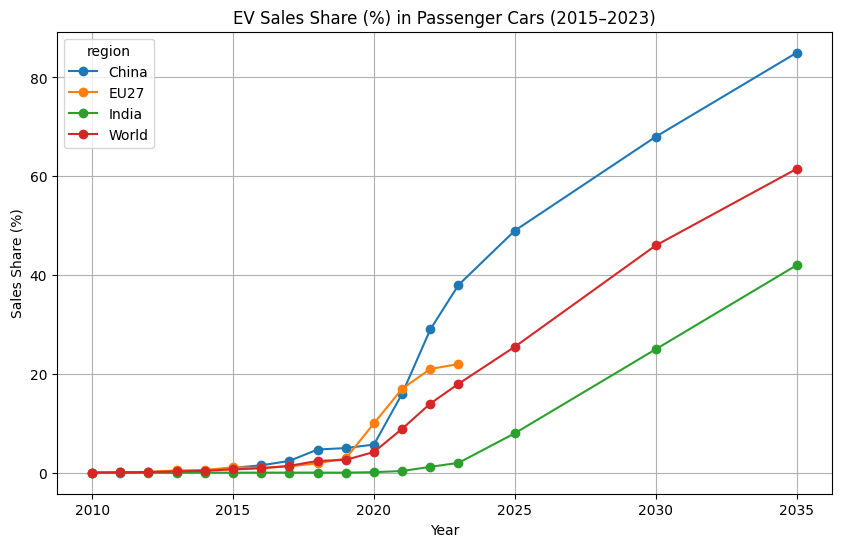

In [ ]:
#Compare India’s EV Sales & Stock Share to Key Regions

regions = ['India', 'China', 'EU27', 'World']


ev_sales_share = iea_global[
    (iea_global['region'].isin(regions)) &
    (iea_global['parameter'] == 'EV sales share') &
    (iea_global['mode'] == 'Cars')
]


ev_sales_share_clean = (
    ev_sales_share.groupby(['year', 'region'], as_index=False)['value'].mean()
)

# Pivot for plotting
pivot_sales = ev_sales_share_clean.pivot(index='year', columns='region', values='value')

# Plot
pivot_sales.plot(figsize=(10,6), marker='o', title='EV Sales Share (%) in Passenger Cars (2015–2023)')
plt.ylabel('Sales Share (%)')
plt.xlabel('Year')
plt.grid(True)
plt.show()



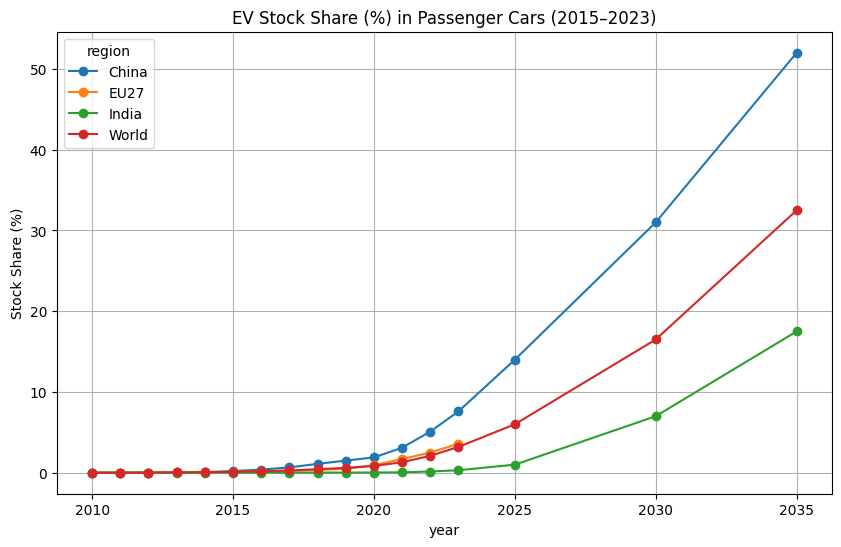

In [ ]:
ev_stock_share = iea_global[
    (iea_global['parameter'] == 'EV stock share') &
    (iea_global['mode'] == 'Cars') &
    (iea_global['region'].isin(regions))
]
ev_stock_share_clean = (
    ev_stock_share.groupby(['year', 'region'], as_index=False)['value'].mean()
)
pivot_stock = ev_stock_share_clean.pivot(index='year', columns='region', values='value')
pivot_stock.plot(figsize=(10,6), marker='o', title='EV Stock Share (%) in Passenger Cars (2015–2023)')
plt.ylabel('Stock Share (%)')
plt.grid(True)
plt.show()


               State  Total_EV_Sales  Charging_Stations
0     Andhra Pradesh         31506.0                327
1  Arunachal Pradesh            21.0                  9
2              Assam         60798.0                 86
3              Bihar         88186.0                124
4         Chandigarh          6333.0                 12
Correlation between statewise EV sales and charging infra: 0.63


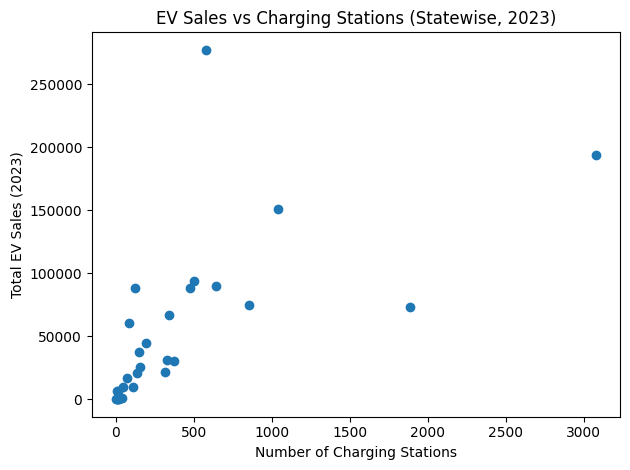

In [ ]:
# Correlation Between Charging Infra & EV Sales

#Aggregate statewise total EV sales for 2023
state_sales_2023 = ev_dataset[ev_dataset['Year'] == 2023].groupby('State')['EV_Sales_Quantity'].sum().reset_index().rename(columns={'EV_Sales_Quantity': 'Total_EV_Sales'})

#Prepare infra data
infra = infra.rename(columns={'No. of Operational PCS': 'Charging_Stations'})

#Merge by State
merged = state_sales_2023.merge(infra, on='State', how='inner')
print(merged.head())

#Calculate correlation
correlation = merged['Total_EV_Sales'].corr(merged['Charging_Stations'])
print(f"Correlation between statewise EV sales and charging infra: {correlation:.2f}")

#Scatter plot
plt.scatter(merged['Charging_Stations'], merged['Total_EV_Sales'])
plt.xlabel('Number of Charging Stations')
plt.ylabel('Total EV Sales (2023)')
plt.title('EV Sales vs Charging Stations (Statewise, 2023)')
plt.tight_layout()
plt.show()


      Year  EV_Sales_Quantity
0   2014.0             2392.0
1   2015.0             7805.0
2   2016.0            49855.0
3   2017.0            87420.0
4   2018.0           130254.0
5   2019.0           166819.0
6   2020.0           124684.0
7   2021.0           331498.0
8   2022.0          1024723.0
9   2023.0          1525179.0
10  2024.0           143182.0


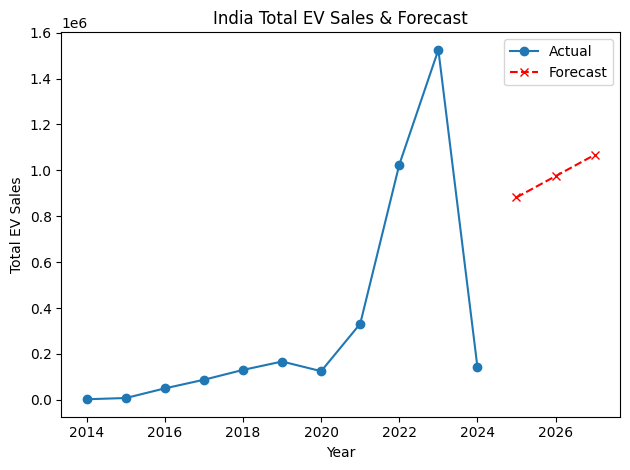

Predicted EV sales for 2025: 882,017
Predicted EV sales for 2026: 974,568
Predicted EV sales for 2027: 1,067,119


In [ ]:
#Forecasting India’s Total EV Sales

# total EV sales by year
yearly_sales = ev_dataset.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()
print(yearly_sales)

# Forecast Using Linear Regression

X = yearly_sales['Year'].values.reshape(-1, 1)
y = yearly_sales['EV_Sales_Quantity'].values

# Fit model
model = LinearRegression()
model.fit(X, y)

# Predict future (next 3 years: 2025, 2026, 2027)
future_years = np.array([2025, 2026, 2027]).reshape(-1, 1)
predicted_sales = model.predict(future_years)

# Plot

plt.plot(yearly_sales['Year'], yearly_sales['EV_Sales_Quantity'], marker='o', label='Actual')
plt.plot(future_years, predicted_sales, marker='x', linestyle='--', color='red', label='Forecast')
plt.xlabel('Year')
plt.ylabel('Total EV Sales')
plt.title('India Total EV Sales & Forecast')
plt.legend()
plt.tight_layout()
plt.show()

# Display predictions
for year, pred in zip(future_years.flatten(), predicted_sales):
    print(f"Predicted EV sales for {year}: {int(pred):,}")


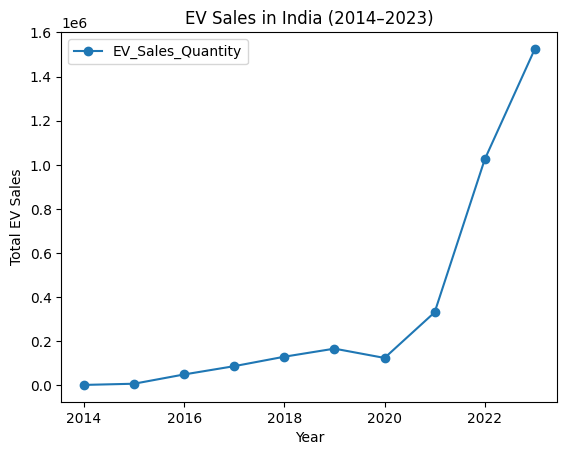

In [ ]:
#ARIMA

# Prepare time series
ev_sales_year = pd.DataFrame({
    'Year': [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023],
    'EV_Sales_Quantity': [2392,7805,49855,87420,130254,166819,124684,331498,1024723,1525179]
})
ev_sales_year.set_index('Year', inplace=True)

# Plot raw data
ev_sales_year.plot(marker='o', title='EV Sales in India (2014–2023)')
plt.ylabel('Total EV Sales')
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

ARIMA Forecast: 10    1.153778e+06
11    4.034666e+05
12    3.035555e+05
Name: predicted_mean, dtype: float64


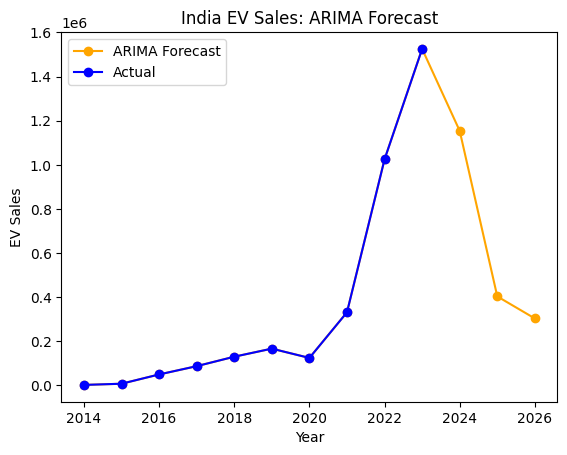

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(ev_sales_year['EV_Sales_Quantity'], order=(2,1,2))
model_fit = model.fit()

# Forecast next 3 years (2024–2026)
forecast = model_fit.forecast(steps=3)
print('ARIMA Forecast:', forecast)

# Add forecast to plot
years = list(ev_sales_year.index) + [2024, 2025, 2026]
sales = list(ev_sales_year['EV_Sales_Quantity']) + list(forecast)
plt.plot(years, sales, marker='o', label='ARIMA Forecast', color='orange')
plt.plot(ev_sales_year.index, ev_sales_year['EV_Sales_Quantity'], marker='o', label='Actual', color='blue')
plt.legend()
plt.title('India EV Sales: ARIMA Forecast')
plt.xlabel('Year')
plt.ylabel('EV Sales')
plt.show()


In [ ]:
infra_df = pd.read_csv('OperationalPC.csv')
print(infra_df.head())


ev_2023_state = ev_dataset[ev_dataset['Year'] == 2023].groupby('State')['EV_Sales_Quantity'].sum().reset_index()
infra_df = infra_df.rename(columns={'No. of Operational PCS': 'Charging_Stations'})


state_sales_infra = pd.merge(ev_2023_state, infra_df, how='left', on='State')

# result
print(state_sales_infra.head())
state_sales_infra = state_sales_infra.rename(columns={'EV_Sales_Quantity': 'Total_EV_Sales'})


               State  No. of Operational PCS
0  Andaman & Nicobar                       3
1     Andhra Pradesh                     327
2  Arunachal Pradesh                       9
3              Assam                      86
4              Bihar                     124
                      State  EV_Sales_Quantity  Charging_Stations
0  Andaman & Nicobar Island               26.0                NaN
1            Andhra Pradesh            31506.0              327.0
2         Arunachal Pradesh               21.0                9.0
3                     Assam            60798.0               86.0
4                     Bihar            88186.0              124.0


In [ ]:
ev_2023_state = ev_dataset[ev_dataset['Year'] == 2023].groupby('State')['EV_Sales_Quantity'].sum().reset_index()

# Merge
state_sales_infra = pd.merge(ev_2023_state, infra_df, how='left', on='State')
state_sales_infra = state_sales_infra.rename(columns={'EV_Sales_Quantity': 'Total_EV_Sales'})

print(state_sales_infra.head())


                      State  Total_EV_Sales  Charging_Stations
0  Andaman & Nicobar Island            26.0                NaN
1            Andhra Pradesh         31506.0              327.0
2         Arunachal Pradesh            21.0                9.0
3                     Assam         60798.0               86.0
4                     Bihar         88186.0              124.0


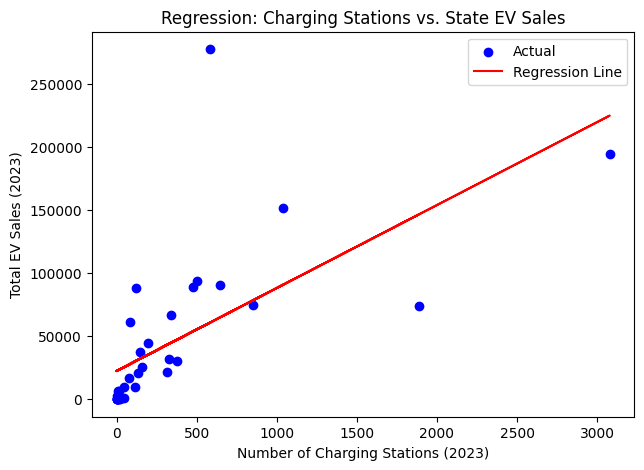

Regression Coefficient (beta): 65.72
Intercept: 22363.20
R² Score: 0.428


In [ ]:
#Charging Infra vs. State EV Sales

X = state_sales_infra[['Charging_Stations']].fillna(0)  # Independent variable
y = state_sales_infra['Total_EV_Sales']                # Dependent variable

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='b', label='Actual')
plt.plot(X, y_pred, color='r', label='Regression Line')
plt.xlabel('Number of Charging Stations (2023)')
plt.ylabel('Total EV Sales (2023)')
plt.title('Regression: Charging Stations vs. State EV Sales')
plt.legend()
plt.show()

print(f"Regression Coefficient (beta): {reg.coef_[0]:.2f}")
print(f"Intercept: {reg.intercept_:.2f}")
print(f"R² Score: {reg.score(X, y):.3f}")


In [ ]:
# data
X = state_sales_infra[['Charging_Stations']].fillna(0)
y = state_sales_infra['Total_EV_Sales']

reg = LinearRegression()
reg.fit(X, y)

# Regression coefficient (slope)
print("Regression Coefficient (Slope):", reg.coef_[0])
# Intercept
print("Intercept:", reg.intercept_)
# R² Score
print("R² Score:", reg.score(X, y))


Regression Coefficient (Slope): 65.72400860525092
Intercept: 22363.197407667507
R² Score: 0.4283804929898185


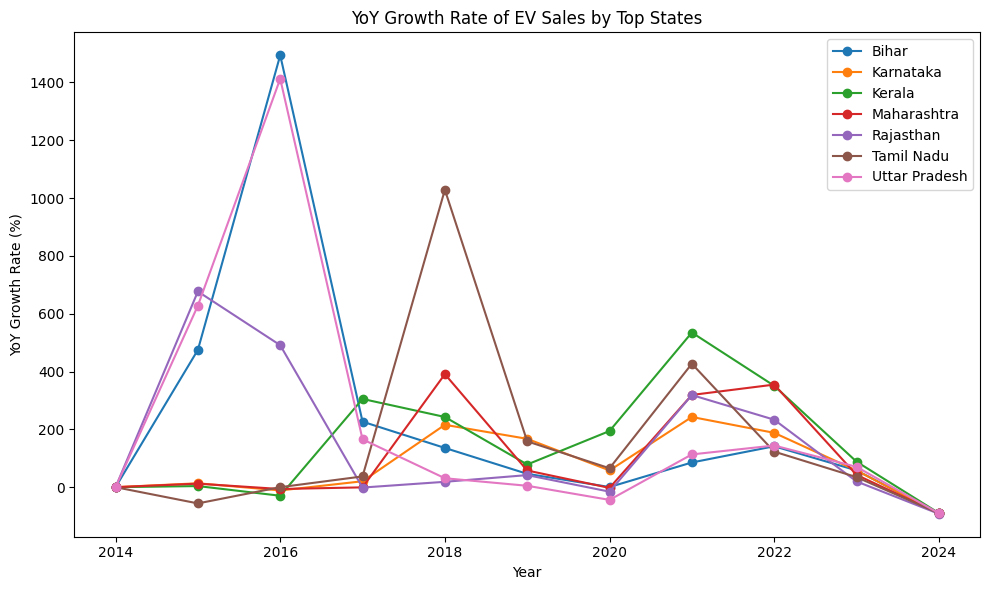

In [ ]:
#Statewise YoY Growth Rates (Top States)

# Calculate total sales by state and year
state_year_sales = ev_dataset.groupby(['State', 'Year'])['EV_Sales_Quantity'].sum().reset_index()

latest_year = int(state_year_sales['Year'].max())
top_states = state_year_sales[state_year_sales['Year'] == latest_year].sort_values('EV_Sales_Quantity', ascending=False)['State'].head(7).tolist()

# Filter only top states for clarity
state_year_sales_top = state_year_sales[state_year_sales['State'].isin(top_states)]

# Pivot for YoY calculation
pivot = state_year_sales_top.pivot(index='Year', columns='State', values='EV_Sales_Quantity')

# Calculate YoY growth (%)
yoy_growth = pivot.pct_change().fillna(0) * 100

# Plot
plt.figure(figsize=(10,6))
for state in yoy_growth.columns:
    plt.plot(yoy_growth.index, yoy_growth[state], marker='o', label=state)
plt.title('YoY Growth Rate of EV Sales by Top States')
plt.ylabel('YoY Growth Rate (%)')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()


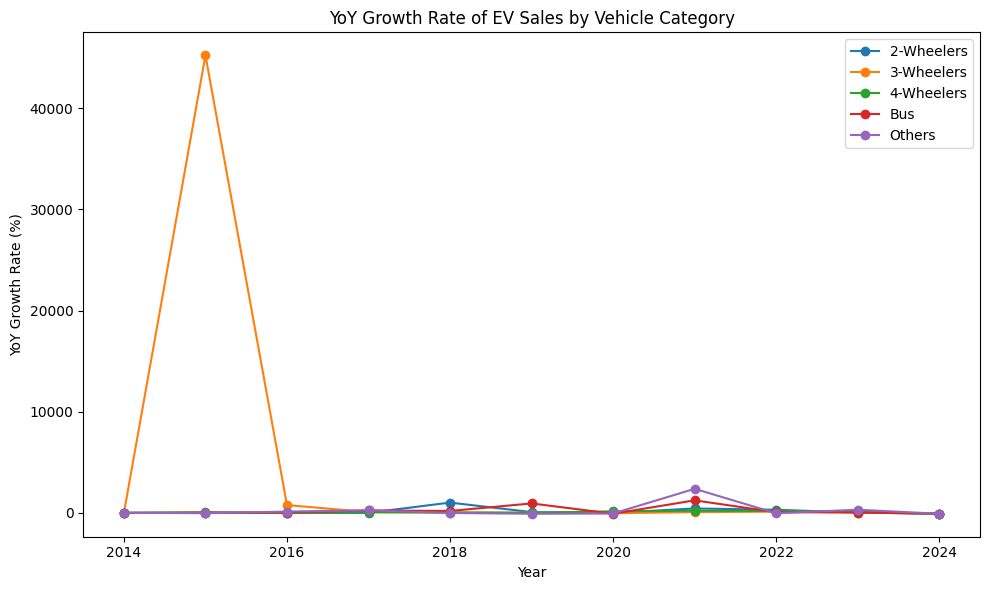

In [ ]:
#Classwise YoY Growth Rates (2W, 3W, 4W, BUS)

# Group by Year and Vehicle_Category (2W, 3W, 4W, BUS)
class_year_sales = ev_dataset.groupby(['Year', 'Vehicle_Category'])['EV_Sales_Quantity'].sum().reset_index()

# Pivot for YoY calculation
pivot_class = class_year_sales.pivot(index='Year', columns='Vehicle_Category', values='EV_Sales_Quantity')

# Calculate YoY growth (%)
yoy_growth_class = pivot_class.pct_change().fillna(0) * 100

# Plot
plt.figure(figsize=(10,6))
for category in yoy_growth_class.columns:
    plt.plot(yoy_growth_class.index, yoy_growth_class[category], marker='o', label=category)
plt.title('YoY Growth Rate of EV Sales by Vehicle Category')
plt.ylabel('YoY Growth Rate (%)')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()


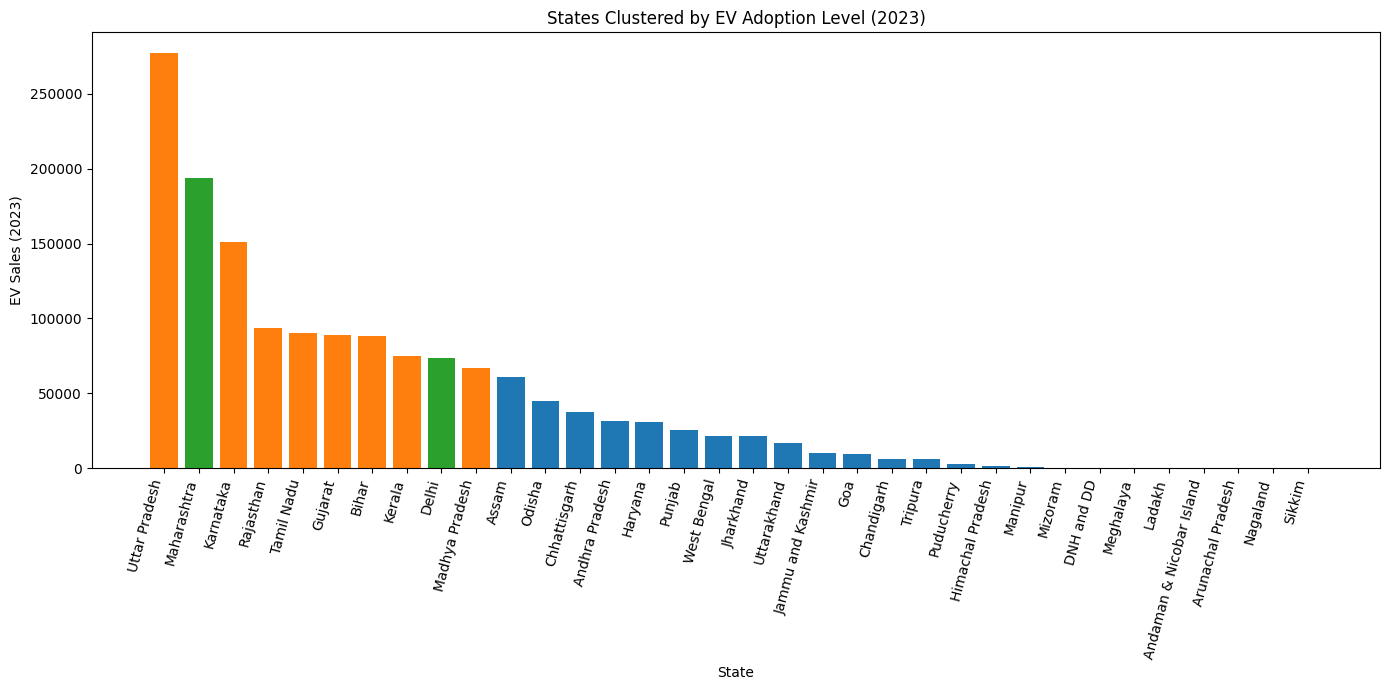

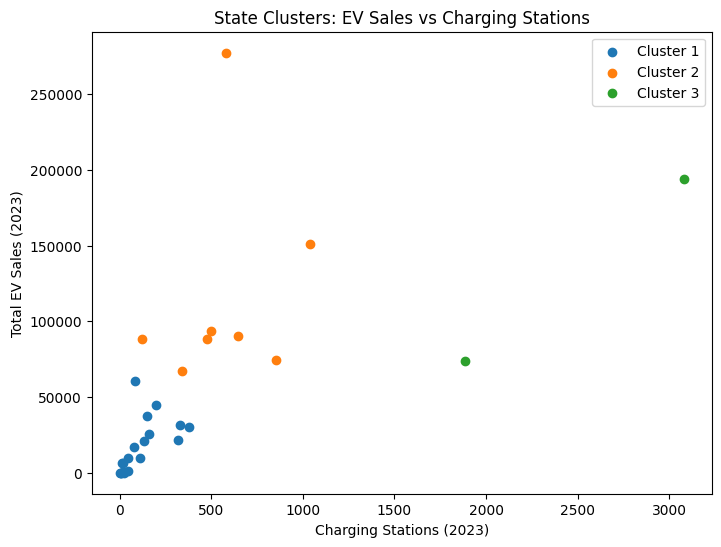

Cluster 1:
['Andaman & Nicobar Island', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Chandigarh', 'Chhattisgarh', 'DNH and DD', 'Goa', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Ladakh', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Sikkim', 'Tripura', 'Uttarakhand', 'West Bengal']

Cluster 2:
['Bihar', 'Gujarat', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Rajasthan', 'Tamil Nadu', 'Uttar Pradesh']

Cluster 3:
['Delhi', 'Maharashtra']



In [ ]:
#merged DataFrame
ev_2023_state = ev_dataset[ev_dataset['Year'] == 2023].groupby('State')['EV_Sales_Quantity'].sum().reset_index()
infra_2023 = infra_df.rename(columns={'No. of Operational PCS': 'Charging_Stations'})
cluster_df = ev_2023_state.merge(infra_2023, on='State', how='left')

#Clustering and plotting
cluster_df = cluster_df.rename(columns={'EV_Sales_Quantity': 'Total_EV_Sales_2023'})

X = cluster_df[['Total_EV_Sales_2023', 'Charging_Stations']].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)
cluster_colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}

plt.figure(figsize=(14,7))
sorted_df = cluster_df.sort_values('Total_EV_Sales_2023', ascending=False)
bars = plt.bar(sorted_df['State'], sorted_df['Total_EV_Sales_2023'],
               color=[cluster_colors[c] for c in sorted_df['Cluster']])
plt.title("States Clustered by EV Adoption Level (2023)")
plt.ylabel("EV Sales (2023)")
plt.xlabel("State")
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
for i in range(3):
    subset = cluster_df[cluster_df['Cluster'] == i]
    plt.scatter(subset['Charging_Stations'], subset['Total_EV_Sales_2023'],
                label=f'Cluster {i+1}', color=cluster_colors[i])
plt.xlabel("Charging Stations (2023)")
plt.ylabel("Total EV Sales (2023)")
plt.title("State Clusters: EV Sales vs Charging Stations")
plt.legend()
plt.show()

for i in range(3):
    members = cluster_df[cluster_df['Cluster'] == i]['State'].tolist()
    print(f"Cluster {i+1}:")
    print(members)
    print()



In [ ]:
#Compare India’s EV Growth Rate vs. Global Benchmarks

#Calculate CAGR for Each Region
import numpy as np

def calculate_cagr(start_value, end_value, num_years):
    return (end_value / start_value) ** (1 / num_years) - 1

regions = ['India', 'China', 'USA', 'EU27', 'World']

cagr_results = []

for region in regions:
    region_data = iea_global[(iea_global['region'] == region) &
                             (iea_global['parameter'] == 'EV stock') &
                             (iea_global['category'] == 'Historical') &
                             (iea_global['unit'] == 'Vehicles')]
    region_data = region_data.sort_values('year')
    start_year, end_year = 2015, 2023

    v_start = region_data[region_data['year'] == start_year]['value'].values
    v_end = region_data[region_data['year'] == end_year]['value'].values
    if len(v_start) > 0 and len(v_end) > 0 and v_start[0] > 0:
        cagr = calculate_cagr(v_start[0], v_end[0], end_year - start_year)
        cagr_results.append({'Region': region, 'CAGR (%)': cagr * 100})
    else:
        cagr_results.append({'Region': region, 'CAGR (%)': np.nan})

import pandas as pd
cagr_df = pd.DataFrame(cagr_results)
print(cagr_df)


  Region   CAGR (%)
0  India -37.688470
1  China  43.164072
2    USA   0.000000
3   EU27  50.926530
4  World  26.361325


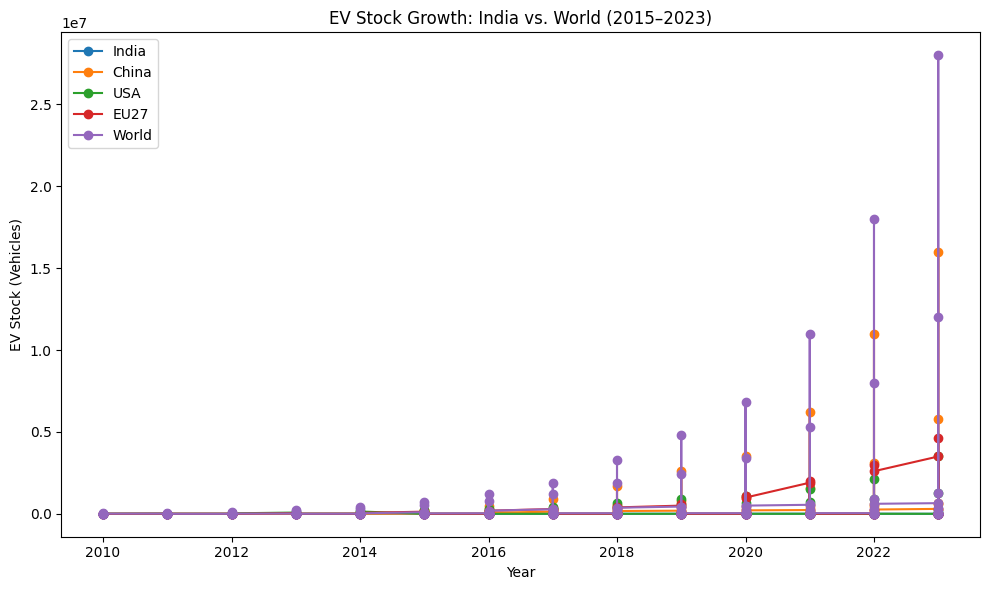

In [ ]:
#Plot the Growth Curves

plt.figure(figsize=(10,6))
for region in regions:
    df = iea_global[(iea_global['region'] == region) &
                    (iea_global['parameter'] == 'EV stock') &
                    (iea_global['category'] == 'Historical') &
                    (iea_global['unit'] == 'Vehicles')]
    plt.plot(df['year'], df['value'], marker='o', label=region)
plt.title("EV Stock Growth: India vs. World (2015–2023)")
plt.xlabel("Year")
plt.ylabel("EV Stock (Vehicles)")
plt.legend()
plt.tight_layout()
plt.show()


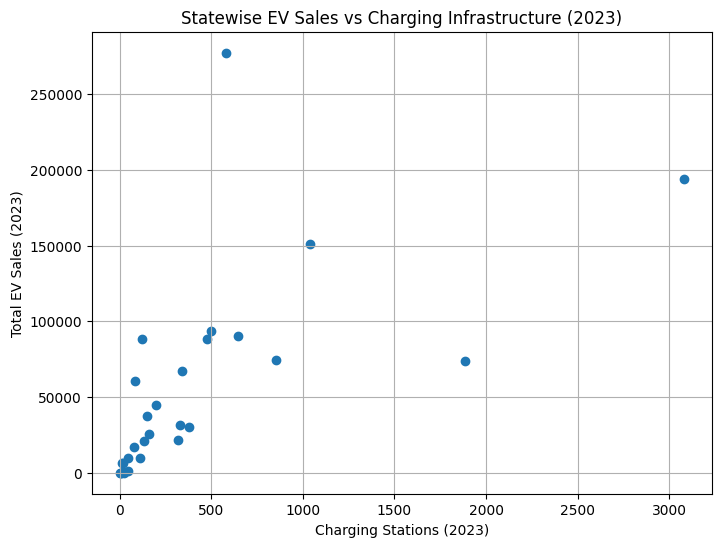

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(cluster_df['Charging_Stations'], cluster_df['Total_EV_Sales_2023'])
plt.xlabel("Charging Stations (2023)")
plt.ylabel("Total EV Sales (2023)")
plt.title("Statewise EV Sales vs Charging Infrastructure (2023)")
plt.grid(True)
plt.show()



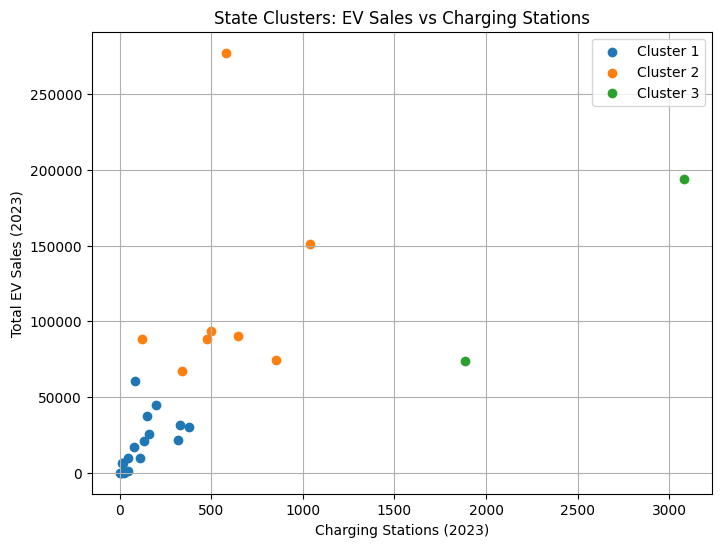

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare the features
X = cluster_df[['Total_EV_Sales_2023', 'Charging_Stations']].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans clustering (3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}

plt.figure(figsize=(8,6))
for i in range(3):
    subset = cluster_df[cluster_df['Cluster'] == i]
    plt.scatter(subset['Charging_Stations'], subset['Total_EV_Sales_2023'],
                label=f'Cluster {i+1}', color=colors[i])
plt.xlabel("Charging Stations (2023)")
plt.ylabel("Total EV Sales (2023)")
plt.title("State Clusters: EV Sales vs Charging Stations")
plt.legend()
plt.grid(True)
plt.show()


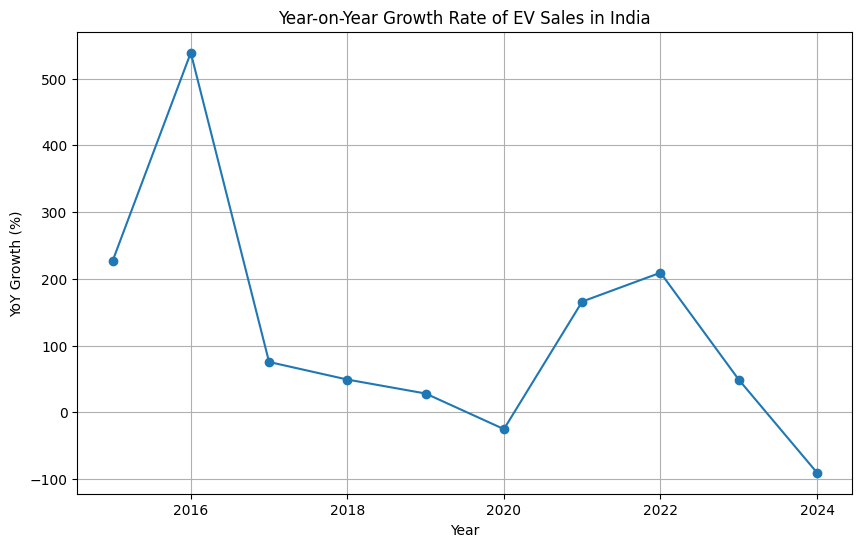

In [ ]:
# Assuming you have a DataFrame with columns 'Year' and 'EV_Sales_Quantity'
ev_sales = ev_dataset.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()
ev_sales = ev_sales.sort_values('Year')
ev_sales['YoY_Growth'] = ev_sales['EV_Sales_Quantity'].pct_change() * 100

plt.figure(figsize=(10,6))
plt.plot(ev_sales['Year'], ev_sales['YoY_Growth'], marker='o')
plt.xlabel("Year")
plt.ylabel("YoY Growth (%)")
plt.title("Year-on-Year Growth Rate of EV Sales in India")
plt.grid(True)
plt.show()


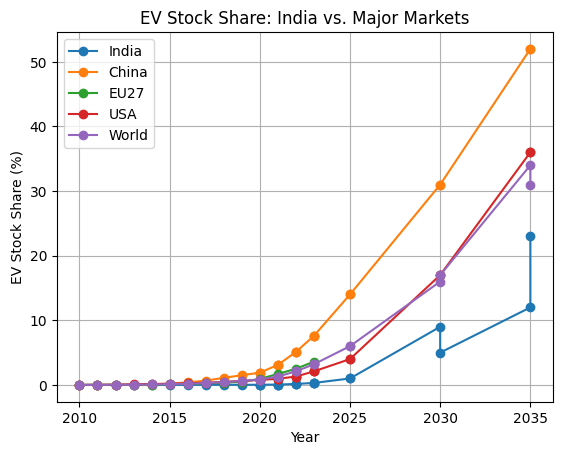

In [ ]:
# Assuming you have 'iea_global' DataFrame and have calculated CAGR for India, China, EU27, USA, World
import matplotlib.pyplot as plt

regions = ['India', 'China', 'EU27', 'USA', 'World']
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]  # Edit as per available data
for region in regions:
    region_data = iea_global[(iea_global['region'] == region) &
                             (iea_global['parameter'] == 'EV stock share') &
                             (iea_global['mode'] == 'Cars')]
    plt.plot(region_data['year'], region_data['value'], marker='o', label=region)
plt.xlabel("Year")
plt.ylabel("EV Stock Share (%)")
plt.title("EV Stock Share: India vs. Major Markets")
plt.legend()
plt.grid(True)
plt.show()


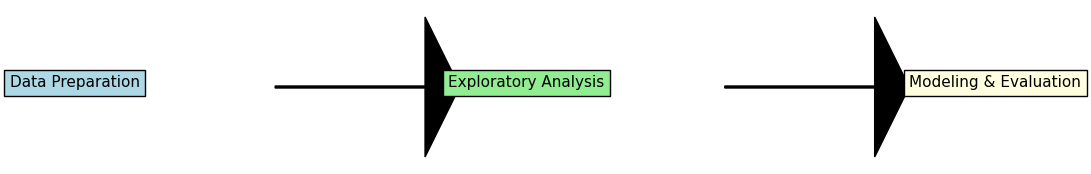

In [ ]:
# (Optional code for a workflow diagram using matplotlib—modify as needed)
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 2))
plt.text(0.05, 0.5, 'Data Preparation', bbox=dict(facecolor='lightblue'), fontsize=11)
plt.arrow(0.28, 0.5, 0.13, 0, head_width=0.07, head_length=0.03, fc='k', ec='k')
plt.text(0.43, 0.5, 'Exploratory Analysis', bbox=dict(facecolor='lightgreen'), fontsize=11)
plt.arrow(0.67, 0.5, 0.13, 0, head_width=0.07, head_length=0.03, fc='k', ec='k')
plt.text(0.83, 0.5, 'Modeling & Evaluation', bbox=dict(facecolor='lightyellow'), fontsize=11)
plt.axis('off')
plt.show()


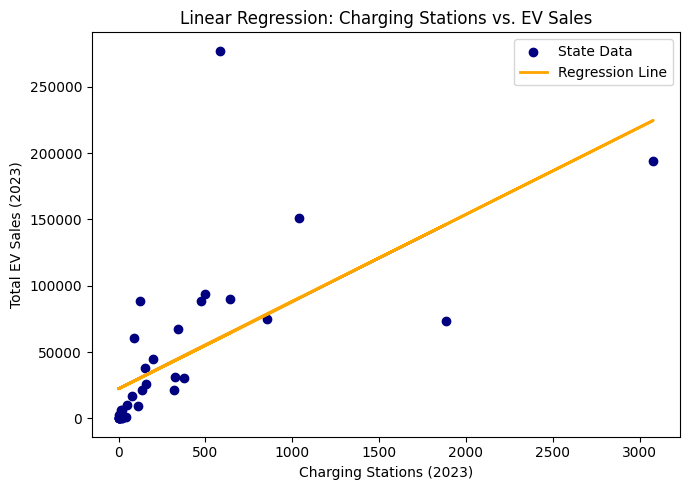

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X = state_sales_infra[['Charging_Stations']].fillna(0)
y = state_sales_infra['Total_EV_Sales']

reg = LinearRegression()
reg.fit(X, y)
y_pred = reg.predict(X)

plt.figure(figsize=(7,5))
plt.scatter(X, y, color='navy', label='State Data')
plt.plot(X, y_pred, color='orange', linewidth=2, label='Regression Line')
plt.xlabel('Charging Stations (2023)')
plt.ylabel('Total EV Sales (2023)')
plt.title('Linear Regression: Charging Stations vs. EV Sales')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
cluster_df = cluster_df.rename(columns={'Total_EV_Sales_x': 'Total_EV_Sales_2023'})


In [ ]:
ev_2023 = ev_dataset[ev_dataset['Year'] == 2023].groupby('State')['EV_Sales_Quantity'].sum().reset_index()
ev_2023 = ev_2023.rename(columns={'EV_Sales_Quantity': 'Total_EV_Sales_2023'})
print(ev_2023.head())


                      State  Total_EV_Sales_2023
0  Andaman & Nicobar Island                 26.0
1            Andhra Pradesh              31506.0
2         Arunachal Pradesh                 21.0
3                     Assam              60798.0
4                     Bihar              88186.0


In [ ]:
import pandas as pd

# Group by state for 2022 and 2023
ev_2022 = ev_dataset[ev_dataset['Year'] == 2022].groupby('State')['EV_Sales_Quantity'].sum().reset_index()
ev_2023 = ev_dataset[ev_dataset['Year'] == 2023].groupby('State')['EV_Sales_Quantity'].sum().reset_index()

# Rename columns for clarity
ev_2022 = ev_2022.rename(columns={'EV_Sales_Quantity': 'Total_EV_Sales_2022'})
ev_2023 = ev_2023.rename(columns={'EV_Sales_Quantity': 'Total_EV_Sales_2023'})


In [ ]:
# Merge sales and infra
cluster_df = ev_2023.merge(ev_2022, on='State', how='left').merge(infra_2023, on='State', how='left')


In [ ]:
cluster_df['YoY_Growth_2023'] = ((cluster_df['Total_EV_Sales_2023'] - cluster_df['Total_EV_Sales_2022']) /
                                 cluster_df['Total_EV_Sales_2022'].replace(0, pd.NA)) * 100
cluster_df['YoY_Growth_2023'] = cluster_df['YoY_Growth_2023'].fillna(0)


<ipython-input-57-3531047043>:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cluster_df['YoY_Growth_2023'] = cluster_df['YoY_Growth_2023'].fillna(0)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Fill NaNs for clustering
X_clust = cluster_df[['Total_EV_Sales_2023', 'Charging_Stations', 'YoY_Growth_2023']].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)


In [ ]:
print(cluster_df.head())
print(cluster_df.columns)


                      State  Total_EV_Sales_2023  Total_EV_Sales_2022  \
0  Andaman & Nicobar Island                 26.0                 23.0   
1            Andhra Pradesh              31506.0              29006.0   
2         Arunachal Pradesh                 21.0                  2.0   
3                     Assam              60798.0              40720.0   
4                     Bihar              88186.0              55752.0   

   Charging_Stations  YoY_Growth_2023  Cluster  
0                NaN        13.043478        0  
1              327.0         8.618906        0  
2                9.0       950.000000        2  
3               86.0        49.307466        0  
4              124.0        58.175491        0  
Index(['State', 'Total_EV_Sales_2023', 'Total_EV_Sales_2022',
       'Charging_Stations', 'YoY_Growth_2023', 'Cluster'],
      dtype='object')


In [ ]:
ev_sales_year = ev_dataset.groupby('Year')['EV_Sales_Quantity'].sum().reset_index()
print(ev_sales_year)

      Year  EV_Sales_Quantity
0   2014.0             2392.0
1   2015.0             7805.0
2   2016.0            49855.0
3   2017.0            87420.0
4   2018.0           130254.0
5   2019.0           166819.0
6   2020.0           124684.0
7   2021.0           331498.0
8   2022.0          1024723.0
9   2023.0          1525179.0
10  2024.0           143182.0


EV Total Cost of Ownership (5 years): ₹ 1254000
ICE Total Cost of Ownership (5 years): ₹ 1220000
Cost Difference (ICE - EV): ₹ -34000


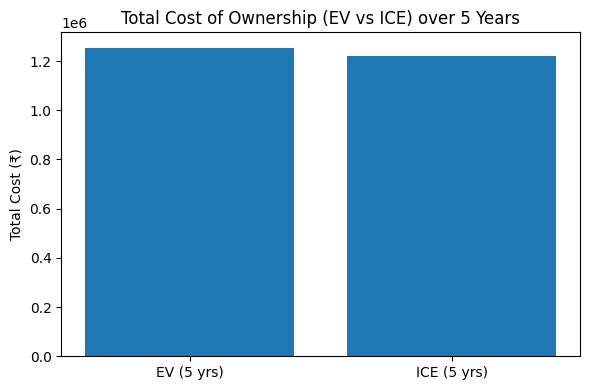

In [ ]:
# Total Cost of Ownership (TCO) Comparison: EV vs ICE

# Assumptions
years_of_ownership = 5
annual_km = 12000

# Prices (in ₹)
ev_initial_cost = 1200000   # Avg EV price
ice_initial_cost = 800000   # Avg ICE vehicle price

# Cost per km (includes fuel + maintenance)
ev_running_cost_per_km = 0.9    # Electricity + service
ice_running_cost_per_km = 7.0   # Petrol/Diesel + service

# Maintenance per year (optional detail)
ev_maintenance = 3000
ice_maintenance = 7000

# Annual running costs
ev_annual_running_cost = ev_running_cost_per_km * annual_km
ice_annual_running_cost = ice_running_cost_per_km * annual_km

# Total ownership costs over 5 years
ev_tco = ev_initial_cost + (ev_annual_running_cost * years_of_ownership)
ice_tco = ice_initial_cost + (ice_annual_running_cost * years_of_ownership)

# Print comparison
print("EV Total Cost of Ownership (5 years): ₹", round(ev_tco))
print("ICE Total Cost of Ownership (5 years): ₹", round(ice_tco))
print("Cost Difference (ICE - EV): ₹", round(ice_tco - ev_tco))

# Optional: Bar plot for visual comparison
import matplotlib.pyplot as plt

labels = ['EV (5 yrs)', 'ICE (5 yrs)']
values = [ev_tco, ice_tco]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title('Total Cost of Ownership (EV vs ICE) over 5 Years')
plt.ylabel('Total Cost (₹)')
plt.tight_layout()
plt.show()


In [ ]:
# Re-import and reset everything cleanly
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# Load fresh data
df = pd.read_excel("EV Adoption Survey (Responses).xlsx")
df.columns = df.columns.str.strip()  # Strip whitespace

# Confirm target column exists
target_col = 'How likely are you to purchase an electric vehicle as your next vehicle?'

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(df[target_col])

# Select some relevant features
feature_cols = ['What is your age group?', 'What is your gender?',
                'How familiar are you with electric vehicle ( EVs)',
                'What is your overall opinion of EVs?']

X = df[feature_cols].copy()

# Encode categorical features
for col in X.columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Print results
print("Random Forest Classification Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Random Forest Classification Accuracy: 0.3902439024390244
Confusion Matrix:
 [[0 3 3 0 0]
 [0 9 2 2 1]
 [0 4 6 0 2]
 [0 2 1 0 0]
 [0 2 3 0 1]]
